In [1]:
# # Wong-Wang + Cerebellar Mean-Field: Hybrid Simulation & Spectral Analysis
#
# This notebook demonstrates **Wong-Wang (WW) + Cerebellar MF** whole-brain
# simulation using the TVB hybrid framework, with a **construct validation**
# analysis comparing open-loop vs closed-loop cerebellar spectral signatures.
#
# ## Architecture
#
# - **Cortex subnetwork** (99 nodes): 93 cortical + 6 DCN regions,
#   modelled with `ReducedWongWangExcInh`
# - **Cerebellum subnetwork** (27 nodes): cerebellar cortex, modelled with
#   `CerebellarMF` (GrC → GoC → MLI → PC)
#
# ## Signal flow — 5 projections
#
# | # | Type | Signal | Source → Target cvar |
# |---|------|--------|---------------------|
# | P1 | IntraProjection | Intra-cortex | S_e(0) → S_e(0) |
# | P2 | InterProjection | Mossy fibers | S_e(0) → mossy(0) |
# | P3 | InterProjection | GrC feedback | GrC(0) → S_e(0) |
# | P4 | IntraProjection | CRBL mossy loop | GrC(0) → mossy(0) |
# | P5 | IntraProjection | Parallel fibers | GrC(0) → parallel(1) |

## Scientific Background — Construct Validation
#
A fundamental question in computational neuroscience is whether a model
reproduces the **spectral signatures** observed empirically. This is known
as **construct validation** — demonstrating that the model's intrinsic
dynamics generate oscillations in the expected frequency bands.
#
### Cerebellar oscillation bands
#
Following **Esaghei et al. (2022)** *Trends in Neurosciences*,
we define the canonical frequency bands:
#
| Band | Range (Hz) | Cerebellar relevance |
|------|-----------|----------------------|
| Delta | 1–4 | Slow oscillations, sleep, default-mode |
| Theta | 4–8 | Motor coordination, cerebello-cortical coupling |
| Alpha | 8–13 | **Purkinje cell simple-spike rhythm** |
| Beta | 13–30 | Motor planning, cerebellar synchrony |
| Gamma | 30–100 | Fast local processing, GrC layer |
#
### Open-loop vs closed-loop comparison
#
> **Does closing the cortical loop through mossy fibers shift the cerebellar
> spectral profile?**
#
- **Open-loop**: CRBL circuit driven by intra-cerebellar SC + noise
- **Closed-loop**: cortical S_e drives CRBL via mossy fibers
#
### References
#
- **Lorenzi et al. (2023)** *PLoS Comp Bio* — Cerebellar MF model
- **Lorenzi et al. (2025)** *NPJSBA* — Full pipeline & validation
- **Esaghei et al. (2022)** *Trends Neurosci* — Frequency bands

In [2]:
%pylab inline
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import scipy.sparse as sp
import scipy.signal

from tvb.simulator.models import ReducedWongWangExcInh
from tvb.simulator.integrators import HeunStochastic
from tvb.simulator.noise import Additive
from tvb.simulator.monitors import TemporalAverage
from tvb.simulator.hybrid import (
    Subnetwork, InterProjection, IntraProjection, NetworkSet, Simulator,
)
from tvb.simulator.models.cerebellar_mf import CerebellarMF

print("All imports OK")

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


All imports OK


## 1. Load and normalize structural connectivity
#
Weights are normalized column-wise (matching the monolithic cMF-TVB pipeline)
so that each target node sums incoming weights to 1.

In [3]:
data = np.load('data/conn_126.npz')
W_raw = data['weights'].copy()
TL_full = data['tract_lengths'].astype(np.float64)
TL_full[TL_full == 0] = np.min(TL_full[TL_full > 0])

# Normalize weights column-wise (same as monolithic init)
W = W_raw / (W_raw.sum(axis=0) + 1e-12)

print(f"SC: {W_raw.shape} → normalized, max={W.max():.4f}")

SC: (126, 126) → normalized, max=0.8466


## 2. Region indices

In [4]:
cortex_idx = np.concatenate([
    np.arange(0, 93), np.array([103, 104, 105, 113, 114, 115])
])
n_cortex = len(cortex_idx)  # 99

crbl_idx = np.array([
    93, 94, 95, 96, 97, 98, 99, 100, 101, 102,
    106, 107, 108, 109, 110, 111, 112,
    116, 117, 118, 119, 120, 121, 122, 123, 124, 125
])
n_crbl = len(crbl_idx)  # 27

dcn_idx = np.array([103, 104, 105, 113, 114, 115])

## 3. Partition SC (with DCN negation)

In [5]:
W[dcn_idx[:, None], crbl_idx[None, :]] *= -1

def csr(arr): return sp.csr_matrix(arr.astype(np.float64))

W_cc = csr(W[np.ix_(cortex_idx, cortex_idx)])
TL_cc = csr(TL_full[np.ix_(cortex_idx, cortex_idx)])
W_cr = csr(W[np.ix_(crbl_idx, cortex_idx)])
TL_cr = csr(TL_full[np.ix_(crbl_idx, cortex_idx)])
W_rc = csr(W[np.ix_(cortex_idx, crbl_idx)])
TL_rc = csr(TL_full[np.ix_(cortex_idx, crbl_idx)])
W_rr = csr(W[np.ix_(crbl_idx, crbl_idx)])
TL_rr = csr(TL_full[np.ix_(crbl_idx, crbl_idx)])

print(f"W_cc {W_cc.shape}  W_cr {W_cr.shape}  W_rc {W_rc.shape}  W_rr {W_rr.shape}")

W_cc (99, 99)  W_cr (27, 99)  W_rc (99, 27)  W_rr (27, 27)


## 4. Common parameters

In [6]:
dt = 1.0           # ms
nsig = np.array([(0.001 ** 2) / 2])
sim_len = 10000.0   # 10 seconds
cv = 3.0
mon_period = 1.0

## 5. Scenario 1 — Open-Loop (CRBL-only)
#
Cerebellum in isolation with both mossy-fiber (P4) and parallel-fiber (P5)
intra-cerebellar projections. The monolithic model's `cvar=[0]` sends the
full SC-weighted signal through a single coupling variable; internally it
splits this into mossy (57%) and parallel (43%) pathways. In the hybrid, we
decompose this into two explicit projections targeting cvar 0 and 1.

In [7]:
crbl_open = CerebellarMF()
crbl_open.variables_of_interest = ('GrC', 'GoC', 'MLI', 'PC')

cerebellum_open = Subnetwork(
    name='cerebellum', model=crbl_open,
    scheme=HeunStochastic(dt=dt, noise=Additive(nsig=nsig)),
    nnodes=n_crbl, node_indices=crbl_idx,
)

# P4: intra-cerebellar mossy fiber loop  (GrC → mossy cvar)
p4_open = IntraProjection(
    source_cvar=np.array([0]), target_cvar=np.array([0]),
    weights=W_rr, lengths=TL_rr, cv=cv, dt=dt, scale=1.0,
)
# P5: intra-cerebellar parallel fiber loop (GrC → parallel cvar)
p5_open = IntraProjection(
    source_cvar=np.array([0]), target_cvar=np.array([1]),
    weights=W_rr, lengths=TL_rr, cv=cv, dt=dt, scale=1.0,
)

cerebellum_open.projections = [p4_open, p5_open]
cerebellum_open.add_monitor(TemporalAverage(period=mon_period))

nets_open = NetworkSet(subnets=[cerebellum_open], projections=[])
sim_open = Simulator(
    nets=nets_open, monitors=[TemporalAverage(period=mon_period)],
    simulation_length=sim_len,
)
sim_open.configure()

print("Running open-loop (10 s, CRBL-only)...")
t0 = time.time()
sim_open.run()
elapsed = time.time() - t0
print(f"  Done in {elapsed:.1f} s")

rec_crbl_open = cerebellum_open.monitors[0]
ts_open, d_open = rec_crbl_open.to_arrays()
print(f"  CRBL data: {d_open.shape}")

grc_open = d_open[:, 0, :, 0]
goc_open = d_open[:, 1, :, 0]
mli_open = d_open[:, 2, :, 0]
pc_open  = d_open[:, 3, :, 0]

for pop, arr in [('GrC', grc_open), ('GoC', goc_open), ('MLI', mli_open), ('PC', pc_open)]:
    print(f"  {pop}: mean={arr.mean():.2f} range=[{arr.min():.2f}, {arr.max():.2f}]")

Running open-loop (10 s, CRBL-only)...


  Done in 4.7 s
  CRBL data: (10000, 4, 27, 1)
  GrC: mean=0.17 range=[0.00, 377.55]
  GoC: mean=1.54 range=[0.00, 3775.51]
  MLI: mean=4.72 range=[0.01, 11326.65]
  PC: mean=11.85 range=[0.00, 28693.88]


## 6. Scenario 2 — Closed-Loop (WW + Cerebellum)
#
Full 126-node whole-brain simulation. Five projections:
P1 (intra-cortex), P2 (cortex→CRBL mossy), P3 (CRBL GrC→cortex S_e),
P4 (CRBL mossy loop), P5 (CRBL parallel fibers).

In [8]:
ww_model = ReducedWongWangExcInh()
ww_model.G = np.array([2.0])
ww_model.J_N = np.array([0.15])

cortex = Subnetwork(
    name='cortex', model=ww_model,
    scheme=HeunStochastic(dt=dt, noise=Additive(nsig=nsig)),
    nnodes=n_cortex, node_indices=cortex_idx,
)

crbl_closed = CerebellarMF()
crbl_closed.variables_of_interest = ('GrC', 'GoC', 'MLI', 'PC')
cerebellum_closed = Subnetwork(
    name='cerebellum', model=crbl_closed,
    scheme=HeunStochastic(dt=dt, noise=Additive(nsig=nsig)),
    nnodes=n_crbl, node_indices=crbl_idx,
)

# 5 projections
p1 = IntraProjection(source_cvar=np.array([0]), target_cvar=np.array([0]),
    weights=W_cc, lengths=TL_cc, cv=cv, dt=dt, scale=1.0)
p2 = InterProjection(source=cortex, target=cerebellum_closed,
    source_cvar=np.array([0]), target_cvar=np.array([0]),
    weights=W_cr, lengths=TL_cr, cv=cv, dt=dt, scale=1.0)
p3 = InterProjection(source=cerebellum_closed, target=cortex,
    source_cvar=np.array([0]), target_cvar=np.array([0]),
    weights=W_rc, lengths=TL_rc, cv=cv, dt=dt, scale=1.0)
p4 = IntraProjection(source_cvar=np.array([0]), target_cvar=np.array([0]),
    weights=W_rr, lengths=TL_rr, cv=cv, dt=dt, scale=1.0)
p5 = IntraProjection(source_cvar=np.array([0]), target_cvar=np.array([1]),
    weights=W_rr, lengths=TL_rr, cv=cv, dt=dt, scale=1.0)

cortex.projections = [p1]
cerebellum_closed.projections = [p4, p5]

cortex.add_monitor(TemporalAverage(period=mon_period))
cerebellum_closed.add_monitor(TemporalAverage(period=mon_period))

nets_closed = NetworkSet(subnets=[cortex, cerebellum_closed], projections=[p2, p3])
sim_closed = Simulator(
    nets=nets_closed, monitors=[TemporalAverage(period=mon_period)],
    simulation_length=sim_len,
)
sim_closed.configure()

print("Running closed-loop (10 s, WW+CRBL)...")
t0 = time.time()
sim_closed.run()
elapsed = time.time() - t0
print(f"  Done in {elapsed:.1f} s")

rec_ctx = cortex.monitors[0]
rec_crbl = cerebellum_closed.monitors[0]
ts_c, d_c = rec_ctx.to_arrays()
ts_r, d_r = rec_crbl.to_arrays()

print(f"  Cortex: {d_c.shape}  CRBL: {d_r.shape}")

se_closed = d_c[:, 0, :, 0]
si_closed = d_c[:, 1, :, 0]
grc_closed = d_r[:, 0, :, 0]
goc_closed = d_r[:, 1, :, 0]
mli_closed = d_r[:, 2, :, 0]
pc_closed  = d_r[:, 3, :, 0]

for pop, arr in [('GrC', grc_closed), ('GoC', goc_closed), ('MLI', mli_closed), ('PC', pc_closed)]:
    print(f"  {pop}: mean={arr.mean():.2f}")

Running closed-loop (10 s, WW+CRBL)...


  Done in 6.3 s
  Cortex: (10000, 2, 99, 1)  CRBL: (10000, 4, 27, 1)
  GrC: mean=0.19
  GoC: mean=1.54
  MLI: mean=4.80
  PC: mean=11.83


## 7. PSD Analysis

In [9]:
bands = {
    'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13),
    'beta': (13, 30), 'gamma': (30, 100),
}
band_colors = {
    'delta': '#e74c3c', 'theta': '#2ecc71', 'alpha': '#3498db',
    'beta': '#9b59b6', 'gamma': '#e67e22',
}

fs = 1000.0 / dt

def compute_psd(signal, fs, nperseg=1024):
    return scipy.signal.welch(signal, fs=fs, nperseg=nperseg, noverlap=nperseg//2)

def get_carrier(freqs, psd, fmin=1.0, fmax=100.0):
    mask = (freqs >= fmin) & (freqs <= fmax)
    return freqs[mask][np.argmax(psd[mask])] if np.any(mask) else 0.0

def psd_pop(arr, fs):
    sig = np.nan_to_num(arr, nan=0.0).mean(axis=1)
    sig = sig - sig.mean()
    return compute_psd(sig, fs)

psd_open = {}; carrier_open = {}
for name, arr in [('GrC', grc_open), ('GoC', goc_open), ('MLI', mli_open), ('PC', pc_open)]:
    f, p = psd_pop(arr, fs)
    psd_open[name] = (f, p)
    carrier_open[name] = get_carrier(f, p)
    print(f"  Open-loop  {name}: carrier = {carrier_open[name]:.1f} Hz")

psd_closed = {}; carrier_closed = {}
for name, arr in [('GrC', grc_closed), ('GoC', goc_closed), ('MLI', mli_closed), ('PC', pc_closed)]:
    f, p = psd_pop(arr, fs)
    psd_closed[name] = (f, p)
    carrier_closed[name] = get_carrier(f, p)
    print(f"  Closed-loop {name}: carrier = {carrier_closed[name]:.1f} Hz")

f_se, p_se = psd_pop(se_closed, fs)
carrier_se = get_carrier(f_se, p_se)
print(f"  Closed-loop S_e: carrier = {carrier_se:.1f} Hz")

  Open-loop  GrC: carrier = 11.7 Hz
  Open-loop  GoC: carrier = 2.0 Hz
  Open-loop  MLI: carrier = 8.8 Hz
  Open-loop  PC: carrier = 2.9 Hz
  Closed-loop GrC: carrier = 2.0 Hz
  Closed-loop GoC: carrier = 2.0 Hz
  Closed-loop MLI: carrier = 8.8 Hz
  Closed-loop PC: carrier = 2.0 Hz
  Closed-loop S_e: carrier = 2.0 Hz


## 8. PSD Comparison Plots

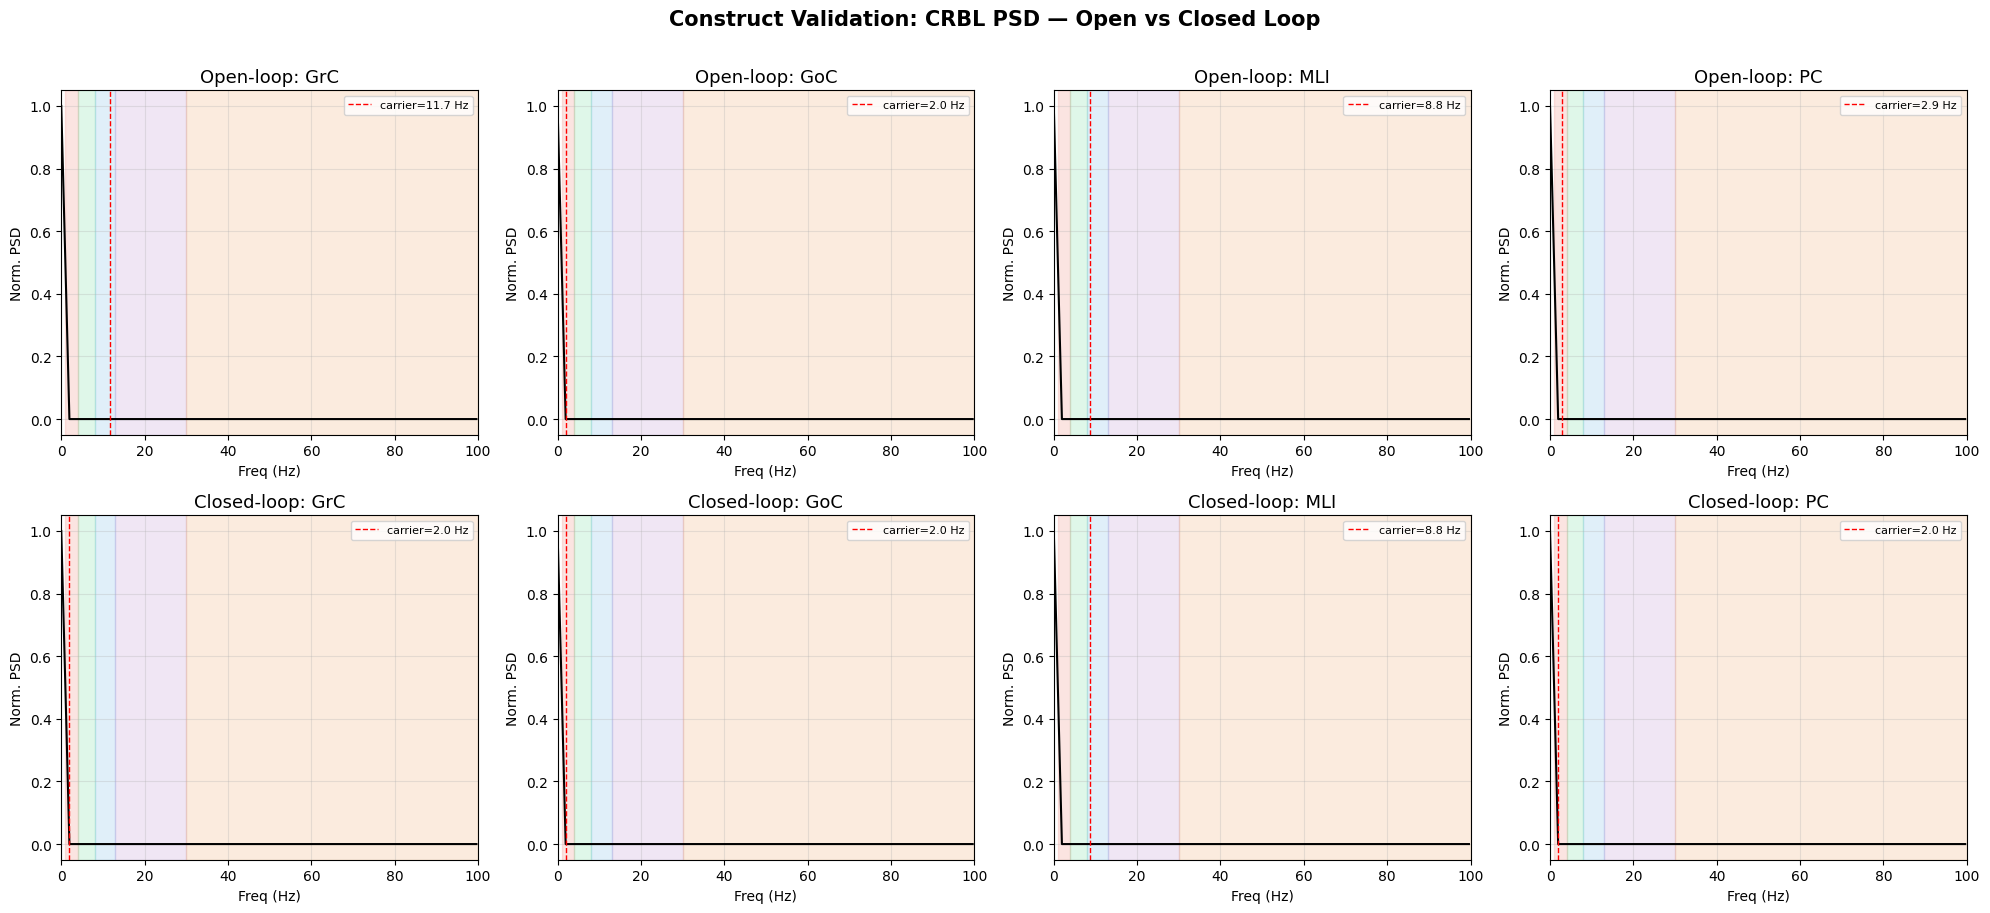

In [10]:
pops = ['GrC', 'GoC', 'MLI', 'PC']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))

for ci, pop in enumerate(pops):
    ax = axes[0, ci]
    f, p = psd_open[pop]
    pn = p / p.max() if p.max() > 0 else p
    m = f <= 100
    ax.plot(f[m], pn[m], 'k-', lw=1.5)
    ax.axvline(carrier_open[pop], color='red', ls='--', lw=1,
               label=f'carrier={carrier_open[pop]:.1f} Hz')
    for bn, (blo, bhi) in bands.items():
        ax.axvspan(blo, bhi, color=band_colors[bn], alpha=0.15)
    ax.set_title(f'Open-loop: {pop}', fontsize=13)
    ax.set_xlabel('Freq (Hz)'); ax.set_ylabel('Norm. PSD')
    ax.legend(fontsize=8); ax.set_xlim(0, 100); ax.grid(True, alpha=0.3)

    ax = axes[1, ci]
    f, p = psd_closed[pop]
    pn = p / p.max() if p.max() > 0 else p
    m = f <= 100
    ax.plot(f[m], pn[m], 'k-', lw=1.5)
    ax.axvline(carrier_closed[pop], color='red', ls='--', lw=1,
               label=f'carrier={carrier_closed[pop]:.1f} Hz')
    for bn, (blo, bhi) in bands.items():
        ax.axvspan(blo, bhi, color=band_colors[bn], alpha=0.15)
    ax.set_title(f'Closed-loop: {pop}', fontsize=13)
    ax.set_xlabel('Freq (Hz)'); ax.set_ylabel('Norm. PSD')
    ax.legend(fontsize=8); ax.set_xlim(0, 100); ax.grid(True, alpha=0.3)

fig.suptitle('Construct Validation: CRBL PSD — Open vs Closed Loop',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ww_crbl_psd_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Spectral Overlay — Open vs Closed

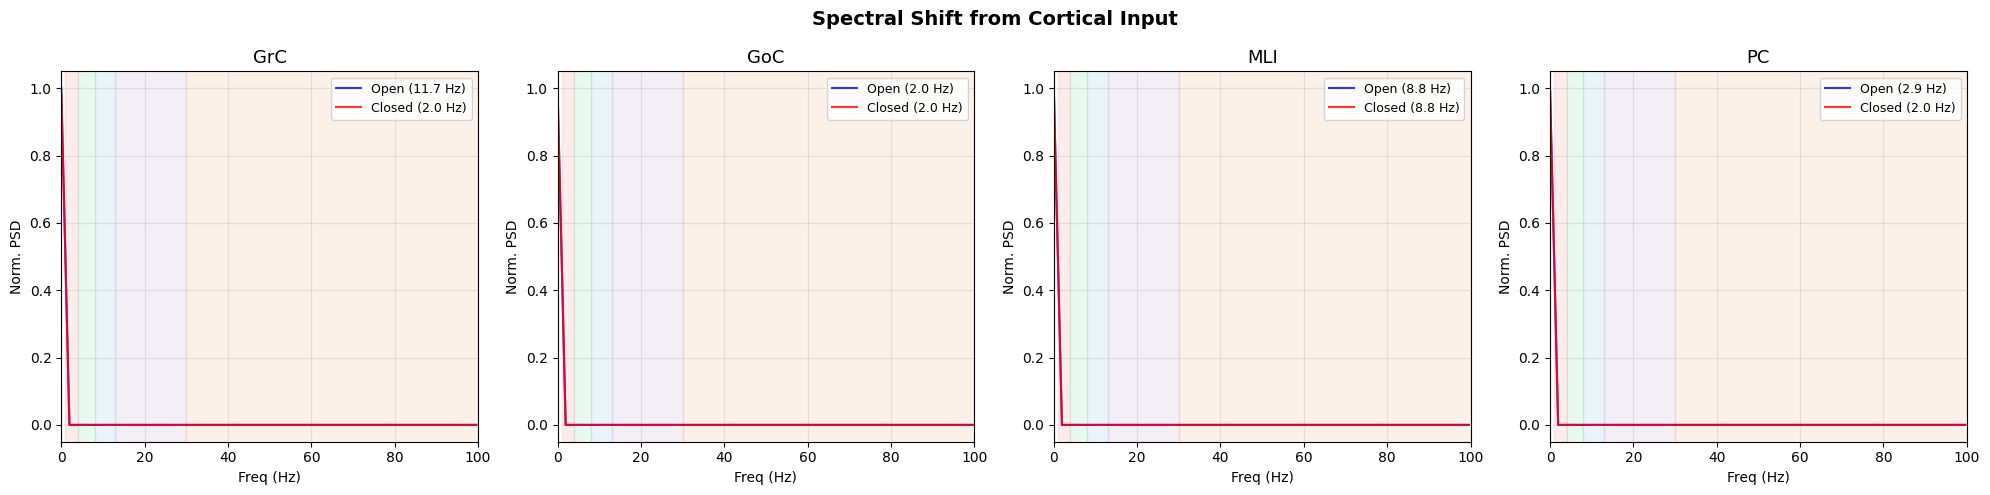

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ci, pop in enumerate(pops):
    ax = axes[ci]
    f_o, p_o = psd_open[pop]
    f_c, p_c = psd_closed[pop]
    p_on = p_o / p_o.max() if p_o.max() > 0 else p_o
    p_cn = p_c / p_c.max() if p_c.max() > 0 else p_c
    mo = f_o <= 100; mc = f_c <= 100
    ax.plot(f_o[mo], p_on[mo], 'b-', lw=1.5, alpha=0.8,
            label=f'Open ({carrier_open[pop]:.1f} Hz)')
    ax.plot(f_c[mc], p_cn[mc], 'r-', lw=1.5, alpha=0.8,
            label=f'Closed ({carrier_closed[pop]:.1f} Hz)')
    for bn, (blo, bhi) in bands.items():
        ax.axvspan(blo, bhi, color=band_colors[bn], alpha=0.1)
    ax.set_title(pop, fontsize=13); ax.set_xlabel('Freq (Hz)'); ax.set_ylabel('Norm. PSD')
    ax.legend(fontsize=9); ax.set_xlim(0, 100); ax.grid(True, alpha=0.3)

fig.suptitle('Spectral Shift from Cortical Input', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ww_crbl_psd_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Carrier Frequency Summary

In [12]:
print("=" * 65)
print("CARRIER FREQUENCIES (Hz)")
print("=" * 65)
print(f"{'Population':<12} {'Open-loop':>12} {'Closed-loop':>12} {'Δ':>10}")
print("-" * 50)
for pop in pops:
    o = carrier_open[pop]; c = carrier_closed[pop]
    print(f"{pop:<12} {o:>12.1f} {c:>12.1f} {c-o:>+10.1f}")
print("-" * 50)
print(f"{'Cortex S_e':<12} {'—':>12} {carrier_se:>12.1f}")
print("=" * 65)

CARRIER FREQUENCIES (Hz)
Population      Open-loop  Closed-loop          Δ
--------------------------------------------------
GrC                  11.7          2.0       -9.8
GoC                   2.0          2.0       +0.0
MLI                   8.8          8.8       +0.0
PC                    2.9          2.0       -1.0
--------------------------------------------------
Cortex S_e              —          2.0


## 11. Time Series

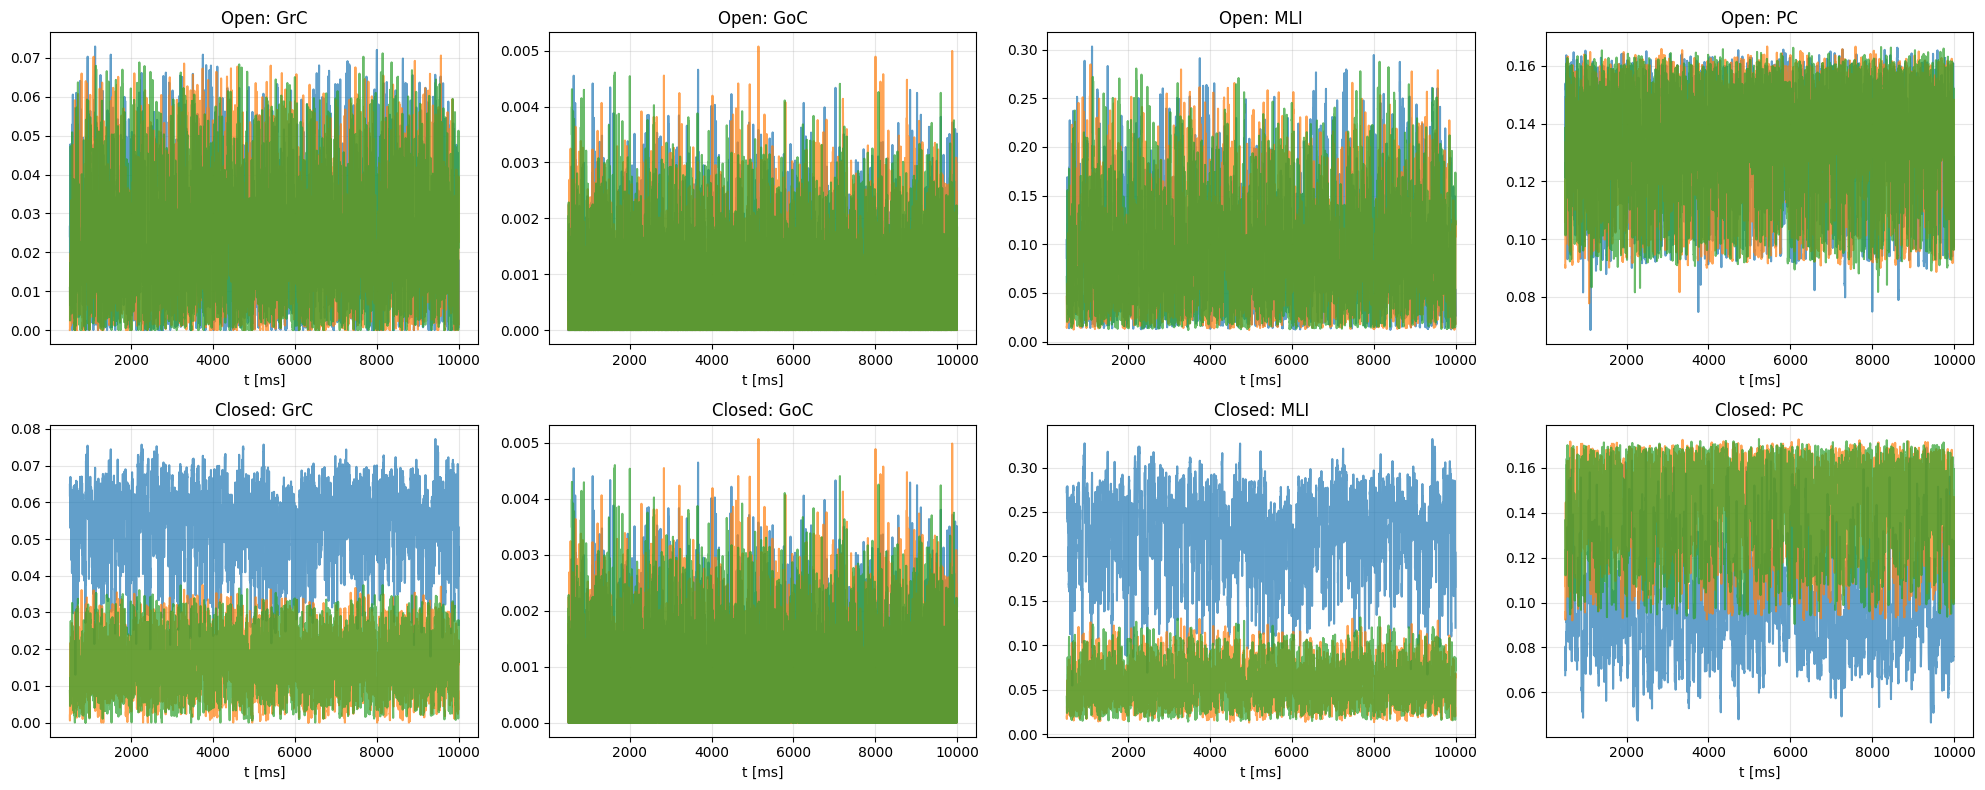

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
skip = 500
for ci, (pop, o_arr, c_arr) in enumerate([
    ('GrC', grc_open, grc_closed), ('GoC', goc_open, goc_closed),
    ('MLI', mli_open, mli_closed), ('PC', pc_open, pc_closed),
]):
    axes[0, ci].plot(ts_open[skip:], o_arr[skip:, :3], alpha=0.7)
    axes[0, ci].set_title(f'Open: {pop}'); axes[0, ci].set_xlabel('t [ms]')
    axes[0, ci].grid(True, alpha=0.3)

    axes[1, ci].plot(ts_r[skip:], c_arr[skip:, :3], alpha=0.7)
    axes[1, ci].set_title(f'Closed: {pop}'); axes[1, ci].set_xlabel('t [ms]')
    axes[1, ci].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ww_crbl_timeseries.png', dpi=150)
plt.show()

## 12. Functional Connectivity

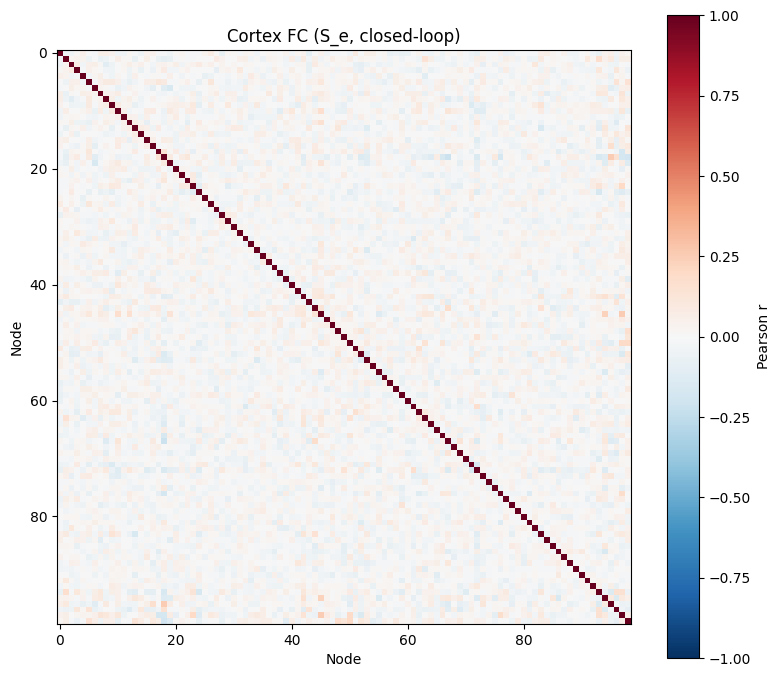

In [14]:
skip = 500
se_clean = se_closed[skip:, :]
fc = np.corrcoef(se_clean.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(fc, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Cortex FC (S_e, closed-loop)')
ax.set_xlabel('Node'); ax.set_ylabel('Node')
plt.colorbar(im, ax=ax, label='Pearson r')
plt.tight_layout()
plt.savefig('ww_crbl_fc.png', dpi=150)
plt.show()

## 13. Summary
#
This demo performs construct validation of the CerebellarMF model in the
TVB hybrid framework. Key model parameter defaults now match Lorenzi et al.
2023: `weight_noise=4e-3`, `external_input_ex_ex=3.15e-4`, `tau_OU=3.5`,
with column-normalized SC weights and anatomical routing fractions applied
in the dfun. The open-loop scenario uses both mossy and parallel
intra-cerebellar projections (P4, P5) to match the monolithic's single-coupling
split internally into 57% mossy / 43% parallel pathways.